# 02 · Análisis topológico descriptivo — BabyFaceValidation

**Notebook 2 de 3.**  
Este notebook describe la forma de los datos en el espacio afectivo valencia–arousal y en un espacio multivariado derivado. El objetivo no es entrenar un clasificador, sino generar evidencia descriptiva sobre componentes, trayectorias, conectividad y posibles grupos topológicos de infantes.

Métodos usados:

- Nube de puntos en espacio valencia–arousal.
- Trayectorias por infante y métricas geométricas: longitud de trayectoria, desplazamiento, tortuosidad, área de envolvente convexa.
- Persistencia de dimensión 0 mediante árbol de expansión mínima, equivalente a la escala de muerte de componentes conectadas en una filtración tipo Vietoris–Rips.
- Curvas de Betti descriptivas para una filtración Vietoris–Rips aproximada sobre la nube final.
- Grafo tipo Mapper simplificado con PCA como lente, cubiertas traslapadas y DBSCAN local.

In [1]:
from pathlib import Path
import re
import math
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CANDIDATES = [
    Path("DataFrameBabyFaceValidacion.xlsx"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx. Coloca el Excel en la misma carpeta del notebook.")

OUTPUT_DIR = Path("babyface_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'S/I', None}

def parse_time_to_seconds(x):
    """Convierte tiempos a segundos. Maneja segundos, milisegundos y formatos tipo HH:MM:SS.mmm."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        value = float(x)
        # Algunos registros están en milisegundos: 16433 -> 16.433 s.
        return value / 1000 if value > 1000 else value
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    if ':' in s:
        try:
            parts = [p.strip() for p in s.split(':')]
            if len(parts) == 3:
                h, m, sec = parts
                return float(h) * 3600 + float(m) * 60 + float(sec)
            if len(parts) == 2:
                m, sec = parts
                return float(m) * 60 + float(sec)
        except Exception:
            pass
    # Casos como 1.00.60 o 1,34,033: se interpretan como minutos, segundos y fracción.
    if re.fullmatch(r'\d+[\.,]\d+[\.,]\d+', s):
        nums = [int(p) for p in re.split(r'[\.,]', s)]
        if len(nums) == 3:
            minutes, seconds, frac = nums
            return minutes * 60 + seconds + frac / (10 ** len(str(frac)))
    try:
        value = float(s.replace(',', '.'))
        return value / 1000 if value > 1000 else value
    except Exception:
        return np.nan

def parse_numeric(x):
    """Convierte a float y manda tokens de error/missing a NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    try:
        return float(s.replace(',', '.'))
    except Exception:
        return np.nan

def parse_day_number(x):
    """Extrae el número de día de etiquetas mixtas como 7E, 7P, 1E 2, 4.2."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    match = re.search(r'\d+(?:\.\d+)?', s)
    return float(match.group(0)) if match else np.nan

def parse_phase(x):
    """Extrae si la etiqueta de día tiene E, P, ambas o ninguna."""
    if pd.isna(x):
        return "sin_fase"
    s = str(x).strip().upper()
    if s in MISSING_TOKENS:
        return "sin_fase"
    has_e = 'E' in s
    has_p = 'P' in s
    if has_e and has_p:
        return "E/P"
    if has_e:
        return "E"
    if has_p:
        return "P"
    return "sin_fase"

def load_and_clean(path=DATA_PATH):
    raw = pd.read_excel(path)
    df = raw.copy()

    # Normalización de comentarios y día.
    df['comentarios'] = df['comentarios'].replace({'NA': np.nan, 'NA ': np.nan, '-': np.nan})
    df['dia_original'] = df['dia'].astype(str)
    df['dia_num'] = df['dia'].apply(parse_day_number)
    df['fase_dia'] = df['dia'].apply(parse_phase)

    time_cols = ['t_total', 't_prueba1', 't_prueba2']
    binary_cols = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
    va_cols = [c for c in df.columns if c.startswith('valence') or c.startswith('arousal')]

    for c in time_cols:
        df[c] = df[c].apply(parse_time_to_seconds)
    for c in binary_cols:
        df[c] = df[c].apply(parse_numeric)
    for c in va_cols:
        df[c] = df[c].apply(parse_numeric)

    valence_cols = [c for c in df.columns if c.startswith('valence')]
    arousal_cols = [c for c in df.columns if c.startswith('arousal')]

    # Variables derivadas para EDA y TDA.
    df['valence_mean'] = df[valence_cols].mean(axis=1, skipna=True)
    df['arousal_mean'] = df[arousal_cols].mean(axis=1, skipna=True)
    df['valence_delta'] = df['valence_final'] - df['valence_inicio']
    df['arousal_delta'] = df['arousal_final'] - df['arousal_inicio']
    df['valence_p1_delta'] = df['valence_p1_after'] - df['valence_p1_before']
    df['valence_p2_delta'] = df['valence_p2_after'] - df['valence_p2_before']
    df['arousal_p1_delta'] = df['arousal_p1_after'] - df['arousal_p1_before']
    df['arousal_p2_delta'] = df['arousal_p2_after'] - df['arousal_p2_before']
    df['aceptacion_score'] = df[['prueba','consume']].mean(axis=1, skipna=True) - df[['rechaza','llora']].mean(axis=1, skipna=True)
    df['va_missing_count'] = df[valence_cols + arousal_cols].isna().sum(axis=1)
    return raw, df

raw, df = load_and_clean()
print(f"Archivo cargado: {DATA_PATH}")
print(f"Dimensiones raw: {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Dimensiones cleaned: {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo cargado: DataFrameBabyFaceValidacion.xlsx
Dimensiones raw: 366 filas x 27 columnas
Dimensiones cleaned: 366 filas x 40 columnas


## 1. Nube afectiva longitudinal

Reorganizamos las mediciones de valencia y arousal en formato largo. Cada fila representa una medición afectiva en una etapa de la exposición: inicio, prueba 1, prueba 2 o final.

In [2]:
stages = [
    ('inicio', 'valence_inicio', 'arousal_inicio'),
    ('p1_before', 'valence_p1_before', 'arousal_p1_before'),
    ('p1_during', 'valence_p1_during', 'arousal_p1_during'),
    ('p1_after', 'valence_p1_after', 'arousal_p1_after'),
    ('p2_before', 'valence_p2_before', 'arousal_p2_before'),
    ('p2_during', 'valence_p2_during', 'arousal_p2_during'),
    ('p2_after', 'valence_p2_after', 'arousal_p2_after'),
    ('final', 'valence_final', 'arousal_final'),
]
long_rows = []
for stage, vcol, acol in stages:
    tmp = df[['id','dia_num','fase_dia','consume','rechaza','prueba',vcol,acol]].copy()
    tmp.columns = ['id','dia_num','fase_dia','consume','rechaza','prueba','valence','arousal']
    tmp['stage'] = stage
    long_rows.append(tmp)
long_va = pd.concat(long_rows, ignore_index=True).dropna(subset=['valence','arousal'])
long_va.to_csv(OUTPUT_DIR / '02_long_valence_arousal.csv', index=False)
print(f"Puntos afectivos válidos en formato largo: {len(long_va)}")
long_va.head()

Puntos afectivos válidos en formato largo: 1933


,id,dia_num,fase_dia,consume,rechaza,prueba,valence,arousal,stage
0,ID1,1.0,sin_fase,1.0,0.0,1.0,0.084054,0.225521,inicio
1,ID1,2.0,sin_fase,1.0,0.0,1.0,0.390882,0.990000,inicio
2,ID1,3.0,sin_fase,1.0,0.0,1.0,0.072386,0.494200,inicio
4,ID1,5.0,sin_fase,0.0,0.0,1.0,0.277303,0.448454,inicio
5,ID1,6.0,sin_fase,1.0,0.0,1.0,0.124406,0.532846,inicio


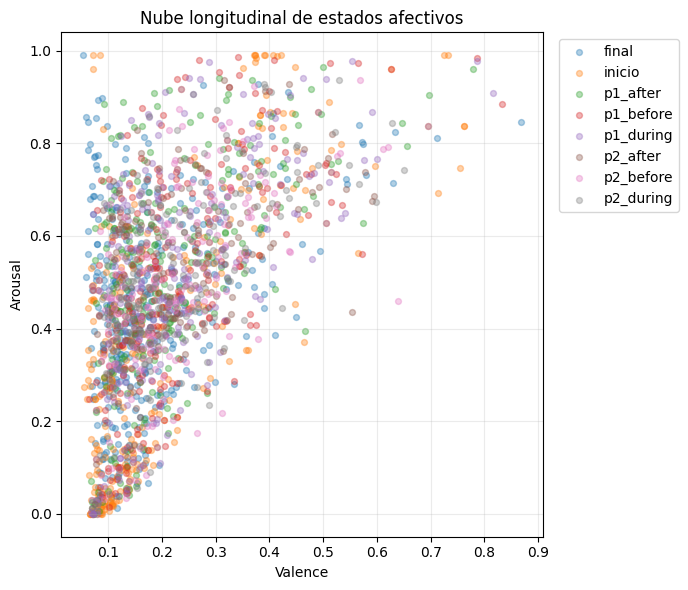

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
for stage, sub in long_va.groupby('stage'):
    ax.scatter(sub['valence'], sub['arousal'], alpha=0.35, s=18, label=stage)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Nube longitudinal de estados afectivos')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_nube_longitudinal_va.png', dpi=160, bbox_inches='tight')
plt.show()

## 2. Trayectorias finales por infante

Para una lectura temporal simple, usamos las coordenadas `valence_final` y `arousal_final` por día. Esto permite observar si cada infante se mueve de forma estable, errática o con cambios abruptos en el espacio afectivo.

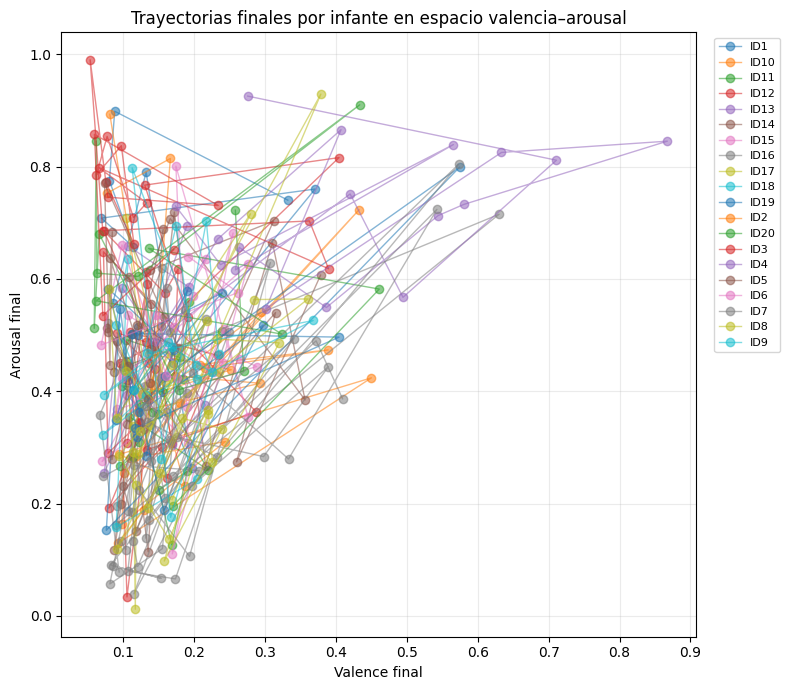

In [4]:
traj_points = df.dropna(subset=['dia_num','valence_final','arousal_final']).sort_values(['id','dia_num'])
fig, ax = plt.subplots(figsize=(8, 7))
for id_value, sub in traj_points.groupby('id'):
    ax.plot(sub['valence_final'], sub['arousal_final'], marker='o', alpha=0.55, linewidth=1, label=id_value)
ax.set_xlabel('Valence final')
ax.set_ylabel('Arousal final')
ax.set_title('Trayectorias finales por infante en espacio valencia–arousal')
ax.grid(alpha=0.25)
# Para no saturar visualmente, dejamos la leyenda fuera y en tamaño pequeño.
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_trayectorias_por_id.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Métricas geométrico-topológicas por infante

Métricas:

- `path_length`: suma de distancias entre puntos consecutivos de la trayectoria.
- `displacement`: distancia entre el primer y último punto afectivo observado.
- `tortuosity`: razón entre longitud total y desplazamiento. Valores altos sugieren trayectorias con retorno, oscilación o exploración irregular.
- `hull_area`: área de la envolvente convexa de los puntos; aproxima dispersión espacial.
- `mst_mean_edge` y `mst_max_edge`: resumen de conectividad H0 dentro de la trayectoria del infante.

In [5]:
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial import ConvexHull

def trajectory_features_for_group(g):
    g = g.dropna(subset=['dia_num','valence_final','arousal_final']).sort_values('dia_num')
    pts = g[['valence_final','arousal_final']].to_numpy()
    out = {'n_puntos_va': len(pts)}
    if len(pts) >= 2:
        diffs = np.diff(pts, axis=0)
        path_length = float(np.linalg.norm(diffs, axis=1).sum())
        displacement = float(np.linalg.norm(pts[-1] - pts[0]))
        out['path_length'] = path_length
        out['displacement'] = displacement
        out['tortuosity'] = path_length / displacement if displacement > 1e-9 else np.nan
        D = squareform(pdist(pts))
        mst = minimum_spanning_tree(D).toarray()
        deaths = mst[mst > 0]
        out['mst_mean_edge'] = float(np.mean(deaths)) if len(deaths) else np.nan
        out['mst_max_edge'] = float(np.max(deaths)) if len(deaths) else np.nan
    else:
        out.update({'path_length': np.nan, 'displacement': np.nan, 'tortuosity': np.nan, 'mst_mean_edge': np.nan, 'mst_max_edge': np.nan})
    if len(pts) >= 3:
        try:
            out['hull_area'] = float(ConvexHull(pts).volume)
        except Exception:
            out['hull_area'] = np.nan
    else:
        out['hull_area'] = np.nan
    return pd.Series(out)

traj_features = df.groupby('id').apply(trajectory_features_for_group).reset_index()
behavior_by_id = df.groupby('id').agg(
    n_registros=('dia_num','count'),
    consume_rate=('consume','mean'),
    prueba_rate=('prueba','mean'),
    rechaza_rate=('rechaza','mean'),
    llora_rate=('llora','mean'),
    toca_rate=('toca','mean'),
    valence_final_media=('valence_final','mean'),
    arousal_final_media=('arousal_final','mean'),
    valence_delta_media=('valence_delta','mean'),
    arousal_delta_media=('arousal_delta','mean')
).reset_index()
traj_features = traj_features.merge(behavior_by_id, on='id', how='left')
traj_features = traj_features.sort_values('id', key=lambda s: s.str.replace('ID','').astype(int))
traj_features.round(3).to_csv(OUTPUT_DIR / '02_trayectoria_features_por_id.csv', index=False)
traj_features.round(3)

,id,n_puntos_va,path_length,displacement,tortuosity,mst_mean_edge,mst_max_edge,hull_area,n_registros,consume_rate,prueba_rate,rechaza_rate,llora_rate,toca_rate,valence_final_media,arousal_final_media,valence_delta_media,arousal_delta_media
0,ID1,11.0,2.392,0.307,7.788,0.099,0.206,0.105,15,0.867,1.000,0.000,0.000,0.000,0.160,0.647,-0.025,0.064
11,ID2,4.0,0.999,0.141,7.088,0.191,0.347,0.024,6,0.833,0.833,0.333,0.200,0.000,0.117,0.718,-0.050,0.330
13,ID3,17.0,2.852,0.155,18.420,0.061,0.135,0.083,19,0.474,0.895,0.316,0.000,0.000,0.132,0.745,-0.058,0.081
14,ID4,18.0,4.502,0.220,20.419,0.096,0.168,0.178,18,0.722,0.889,0.611,0.444,0.667,0.417,0.709,-0.005,-0.002
15,ID5,16.0,2.720,0.120,22.738,0.050,0.120,0.032,16,0.938,0.875,0.250,0.000,0.125,0.112,0.525,-0.055,0.036
16,ID6,8.0,0.992,0.196,5.059,0.084,0.113,0.033,9,0.444,0.444,0.667,0.222,0.000,0.168,0.524,0.046,0.089
17,ID7,31.0,8.655,0.273,31.683,0.060,0.253,0.156,35,0.229,0.343,0.857,0.057,0.543,0.228,0.343,0.016,0.064
18,ID8,25.0,5.866,0.374,15.672,0.069,0.235,0.134,26,0.538,0.692,0.500,0.000,0.808,0.193,0.387,0.009,0.129
19,ID9,14.0,3.402,0.190,17.933,0.079,0.208,0.097,15,1.000,1.000,0.000,0.000,1.000,0.180,0.480,-0.015,0.175
1,ID10,22.0,4.462,0.192,23.256,0.061,0.229,0.103,23,0.087,0.435,0.913,0.087,0.478,0.203,0.366,0.030,0.092


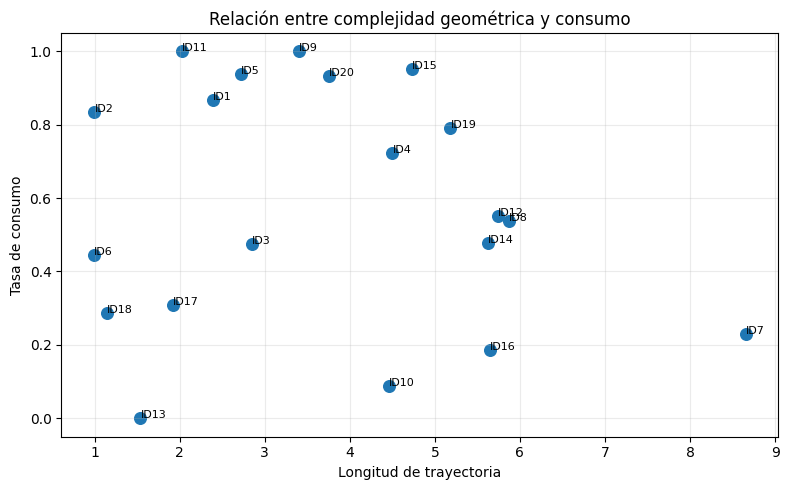

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(traj_features['path_length'], traj_features['consume_rate'], s=70)
for _, row in traj_features.iterrows():
    ax.text(row['path_length'], row['consume_rate'], row['id'], fontsize=8)
ax.set_xlabel('Longitud de trayectoria')
ax.set_ylabel('Tasa de consumo')
ax.set_title('Relación entre complejidad geométrica y consumo')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_path_length_vs_consume.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Persistencia H0 global mediante MST

En una filtración Vietoris–Rips, las componentes conectadas nacen en escala 0 y mueren cuando se conectan con otra componente. Para dimensión 0, las escalas de muerte se pueden obtener desde las aristas del árbol de expansión mínima sobre la matriz de distancias.

In [7]:
from sklearn.preprocessing import StandardScaler

final_cloud = df[['valence_final','arousal_final']].dropna().copy()
X_final = StandardScaler().fit_transform(final_cloud)
D = squareform(pdist(X_final))
mst = minimum_spanning_tree(D).toarray()
h0_deaths = np.sort(mst[mst > 0])
h0_summary = pd.DataFrame({
    'métrica': ['n_puntos', 'n_muertes_H0', 'muerte_mediana', 'muerte_p90', 'muerte_p95', 'muerte_max'],
    'valor': [len(X_final), len(h0_deaths), np.median(h0_deaths), np.percentile(h0_deaths, 90), np.percentile(h0_deaths, 95), np.max(h0_deaths)]
})
h0_summary['valor'] = h0_summary['valor'].astype(float).round(4)
h0_summary.to_csv(OUTPUT_DIR / '02_h0_mst_summary.csv', index=False)
h0_summary

,métrica,valor
0,n_puntos,345.0000
1,n_muertes_H0,344.0000
2,muerte_mediana,0.0987
3,muerte_p90,0.2098
4,muerte_p95,0.3173
5,muerte_max,1.3496


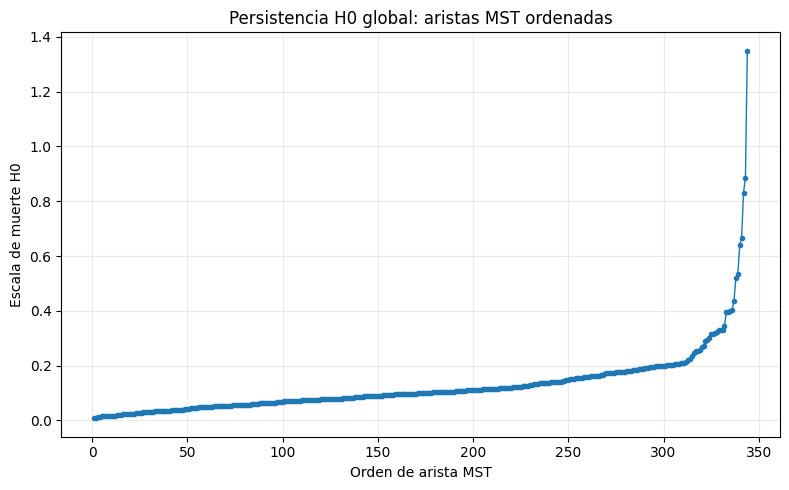

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(h0_deaths) + 1), h0_deaths, marker='.', linewidth=1)
ax.set_xlabel('Orden de arista MST')
ax.set_ylabel('Escala de muerte H0')
ax.set_title('Persistencia H0 global: aristas MST ordenadas')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_h0_mst_deaths.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Curvas de Betti descriptivas con Vietoris–Rips aproximado

Construimos una filtración por umbrales `epsilon` sobre la nube final estandarizada. Reportamos:

- `beta0`: número de componentes conectadas.
- `beta1_graph`: ciclos independientes en el grafo 1-esqueleto, antes de llenar triángulos.
- `beta1_clique_aprox`: aproximación de ciclos no rellenados al descontar triángulos como 2-símplices. En esta representación 2D es una lectura descriptiva, no una sustitución de una librería TDA formal.

In [9]:
import networkx as nx

def betti_curves_rips_approx(X, n_eps=24):
    D = squareform(pdist(X))
    nonzero = D[D > 0]
    eps_grid = np.linspace(np.percentile(nonzero, 5), np.percentile(nonzero, 90), n_eps)
    rows = []
    n = len(X)
    for eps in eps_grid:
        G = nx.Graph()
        G.add_nodes_from(range(n))
        ii, jj = np.where(np.triu(D <= eps, 1))
        G.add_edges_from(zip(ii.tolist(), jj.tolist()))
        V = n
        E = G.number_of_edges()
        C = nx.number_connected_components(G)
        beta1_graph = E - V + C
        # Conteo de triángulos clique para aproximar relleno de 2-símplices.
        adj = [set(G.neighbors(i)) for i in range(n)]
        triangles = 0
        for i in range(n):
            for j in adj[i]:
                if j > i:
                    triangles += sum(1 for k in adj[i].intersection(adj[j]) if k > j)
        beta1_clique_aprox = max(beta1_graph - triangles, 0)
        rows.append({
            'epsilon': eps,
            'beta0': C,
            'beta1_graph': beta1_graph,
            'triangles': triangles,
            'beta1_clique_aprox': beta1_clique_aprox,
            'edges': E
        })
    return pd.DataFrame(rows)

betti_curves = betti_curves_rips_approx(X_final, n_eps=24)
betti_curves.round(4).to_csv(OUTPUT_DIR / '02_betti_curves.csv', index=False)
betti_curves.round(3).head(10)

,epsilon,beta0,beta1_graph,triangles,beta1_clique_aprox,edges
0,0.345,14,2636,14657,0,2967
1,0.465,8,4772,44375,0,5109
2,0.584,6,7397,101313,0,7736
3,0.704,4,10219,190645,0,10560
4,0.824,4,13255,316808,0,13596
5,0.944,2,16421,485465,0,16764
6,1.063,2,19591,690403,0,19934
7,1.183,2,22704,929864,0,23047
8,1.303,2,25737,1197680,0,26080
9,1.423,1,28668,1491718,0,29012


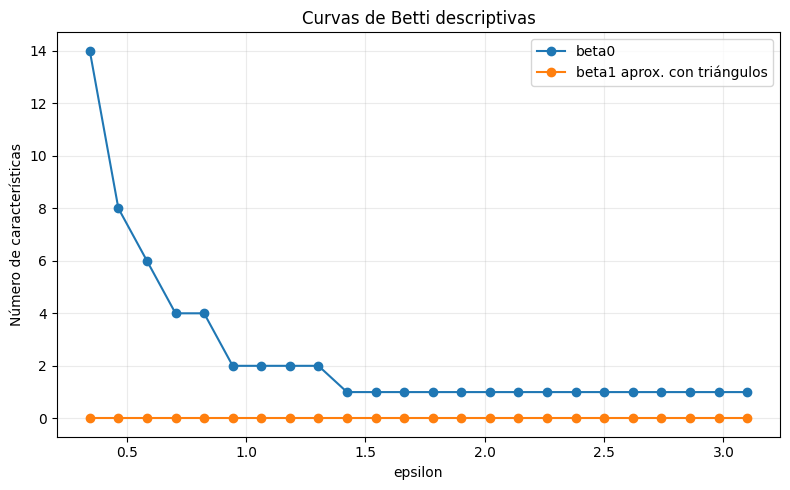

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(betti_curves['epsilon'], betti_curves['beta0'], marker='o', label='beta0')
ax.plot(betti_curves['epsilon'], betti_curves['beta1_clique_aprox'], marker='o', label='beta1 aprox. con triángulos')
ax.set_xlabel('epsilon')
ax.set_ylabel('Número de características')
ax.set_title('Curvas de Betti descriptivas')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_betti_curves.png', dpi=160, bbox_inches='tight')
plt.show()

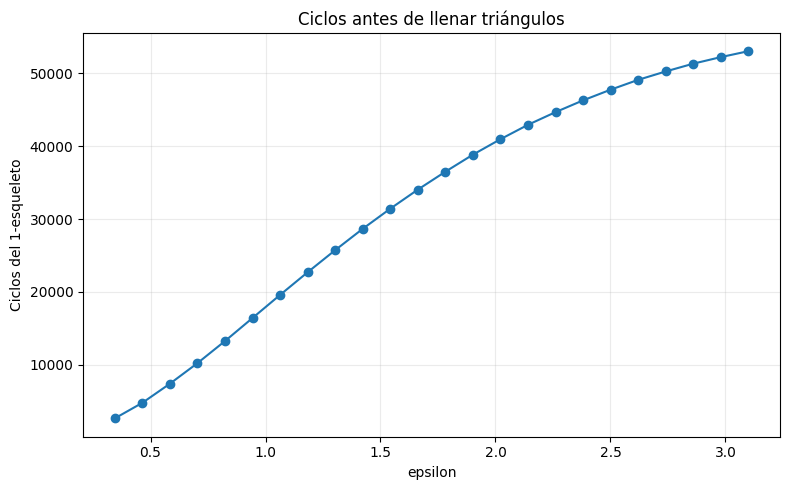

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(betti_curves['epsilon'], betti_curves['beta1_graph'], marker='o')
ax.set_xlabel('epsilon')
ax.set_ylabel('Ciclos del 1-esqueleto')
ax.set_title('Ciclos antes de llenar triángulos')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_beta1_graph.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Grafo tipo Mapper simplificado

Construimos un grafo descriptivo inspirado en Mapper:

1. Espacio multivariado: valencia, arousal, deltas, tiempos y variables conductuales.
2. Escalamiento estándar.
3. Lente: primera componente principal.
4. Cubierta: intervalos traslapados.
5. Clustering local: DBSCAN dentro de cada intervalo.
6. Conexión: dos nodos se conectan si comparten observaciones por el traslape.

In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

feature_cols = [
    'valence_final','arousal_final','valence_mean','arousal_mean',
    'valence_delta','arousal_delta','t_total',
    'prueba','consume','rechaza','llora','toca','dia_num'
]
mapper_df = df[feature_cols + ['id']].copy()
X = mapper_df[feature_cols].replace([np.inf, -np.inf], np.nan)
valid_rows = X.notna().sum(axis=1) >= 8
mapper_df = mapper_df[valid_rows].copy()
X = X[valid_rows].fillna(X[valid_rows].median(numeric_only=True))
X_scaled = StandardScaler().fit_transform(X)
lens = PCA(n_components=2, random_state=42).fit_transform(X_scaled)[:, 0]
mapper_df['lens_pc1'] = lens

n_intervals = 8
overlap = 0.35
lo, hi = lens.min(), lens.max()
width = (hi - lo) / (n_intervals - (n_intervals - 1) * overlap)
step = width * (1 - overlap)
intervals = [(lo + i * step, lo + i * step + width) for i in range(n_intervals)]

node_members = []
node_attrs = []
node_id = 0
for interval_idx, (a, b) in enumerate(intervals):
    mask = (lens >= a) & (lens <= b)
    local_indices = np.where(mask)[0]
    if len(local_indices) < 5:
        continue
    Xi = X_scaled[local_indices]
    if len(local_indices) >= 6:
        nn = NearestNeighbors(n_neighbors=min(5, len(local_indices))).fit(Xi)
        dists, _ = nn.kneighbors(Xi)
        eps = max(float(np.median(dists[:, -1])), 0.6)
    else:
        eps = 0.8
    labels = DBSCAN(eps=eps, min_samples=3).fit_predict(Xi)
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        members_pos = local_indices[labels == lab]
        if len(members_pos) < 3:
            continue
        original_indices = set(mapper_df.index[members_pos])
        sub = mapper_df.iloc[members_pos]
        node_members.append(original_indices)
        node_attrs.append({
            'node': node_id,
            'interval': interval_idx,
            'n': len(members_pos),
            'consume_rate': sub['consume'].mean(),
            'rechaza_rate': sub['rechaza'].mean(),
            'valence_final_mean': sub['valence_final'].mean(),
            'arousal_final_mean': sub['arousal_final'].mean(),
            'lens_mean': sub['lens_pc1'].mean(),
        })
        node_id += 1

G = nx.Graph()
G.add_nodes_from(range(len(node_members)))
for i, j in itertools.combinations(range(len(node_members)), 2):
    shared = node_members[i].intersection(node_members[j])
    if len(shared) > 0:
        G.add_edge(i, j, weight=len(shared))

node_table = pd.DataFrame(node_attrs)
node_table.round(3).to_csv(OUTPUT_DIR / '02_mapper_nodes.csv', index=False)
mapper_summary = pd.DataFrame({
    'métrica': ['filas_usadas', 'nodos_mapper', 'aristas_mapper', 'componentes_mapper'],
    'valor': [len(mapper_df), G.number_of_nodes(), G.number_of_edges(), nx.number_connected_components(G) if G.number_of_nodes() else 0]
})
mapper_summary.to_csv(OUTPUT_DIR / '02_mapper_summary.csv', index=False)
mapper_summary

,métrica,valor
0,filas_usadas,357
1,nodos_mapper,16
2,aristas_mapper,13
3,componentes_mapper,3


In [13]:
node_table.round(3)

,node,interval,n,consume_rate,rechaza_rate,valence_final_mean,arousal_final_mean,lens_mean
0,0,0,31,0.000,1.000,0.122,0.252,-2.986
1,1,0,13,0.000,1.000,0.125,0.153,-2.946
2,2,1,29,0.000,1.000,0.168,0.446,-2.343
3,3,1,25,0.000,1.000,0.180,0.407,-2.080
4,4,1,3,0.000,1.000,0.109,0.223,-1.720
5,5,2,32,0.031,0.875,0.180,0.444,-1.296
6,6,2,5,0.000,1.000,0.242,0.600,-1.328
7,7,3,33,0.394,0.455,0.139,0.403,-0.316
8,8,3,3,0.000,1.000,0.294,0.541,-0.751
9,9,4,13,1.000,0.000,0.145,0.472,0.849


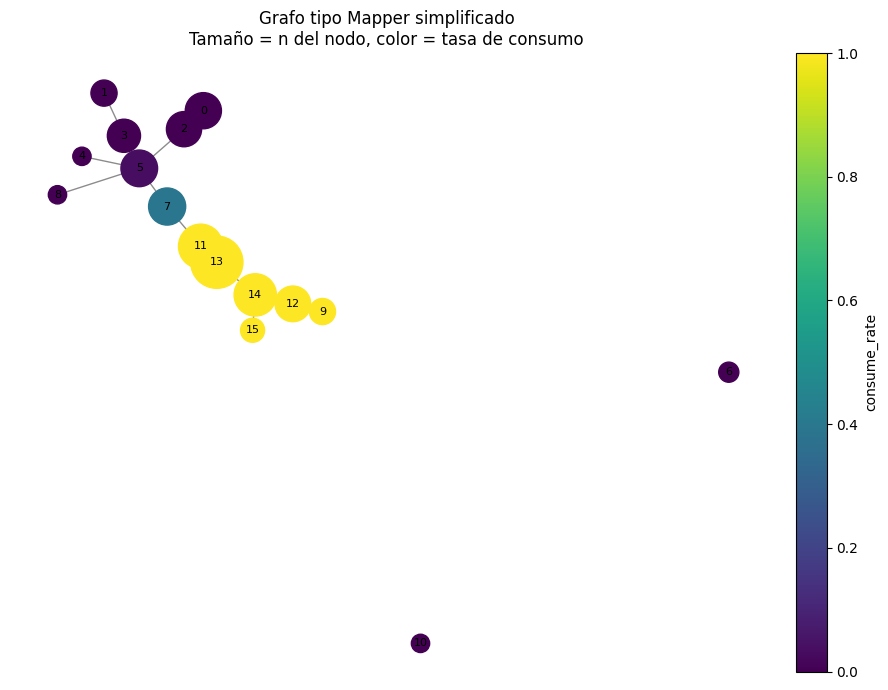

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, seed=42, weight='weight')
    sizes = [120 + 18 * node_table.loc[node_table['node'] == n, 'n'].iloc[0] for n in G.nodes]
    node_colors = [node_table.loc[node_table['node'] == n, 'consume_rate'].iloc[0] for n in G.nodes]
    nx.draw_networkx_edges(G, pos, alpha=0.45, ax=ax)
    nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=node_colors, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('consume_rate')
ax.set_title('Grafo tipo Mapper simplificado\nTamaño = n del nodo, color = tasa de consumo')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_mapper_graph.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Agrupación descriptiva de infantes con métricas topológicas

Usamos K-Means sobre métricas por infante para obtener una lectura exploratoria. La interpretación del cluster se asigna a partir de tasas de consumo/rechazo y complejidad de trayectoria; no es una etiqueta clínica ni causal.

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_cols = ['consume_rate','rechaza_rate','llora_rate','valence_final_media','arousal_final_media','path_length','tortuosity','hull_area','mst_max_edge']
Xc = traj_features[cluster_cols].replace([np.inf, -np.inf], np.nan)
Xc_imp = Xc.fillna(Xc.median(numeric_only=True))
Xc_scaled = StandardScaler().fit_transform(Xc_imp)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
traj_features['cluster_topologico'] = km.fit_predict(Xc_scaled)

cluster_means = traj_features.groupby('cluster_topologico').agg(
    n=('id','count'),
    consume_rate=('consume_rate','mean'),
    rechaza_rate=('rechaza_rate','mean'),
    valence_final_media=('valence_final_media','mean'),
    arousal_final_media=('arousal_final_media','mean'),
    path_length=('path_length','mean'),
    tortuosity=('tortuosity','mean'),
    hull_area=('hull_area','mean'),
    mst_max_edge=('mst_max_edge','mean')
).reset_index()

labels = {}
for _, row in cluster_means.iterrows():
    if row['consume_rate'] >= cluster_means['consume_rate'].max() - 1e-9 and row['rechaza_rate'] <= cluster_means['rechaza_rate'].median():
        labels[int(row['cluster_topologico'])] = 'aceptación alta'
    elif row['rechaza_rate'] >= cluster_means['rechaza_rate'].max() - 1e-9 or row['consume_rate'] <= cluster_means['consume_rate'].min() + 1e-9:
        labels[int(row['cluster_topologico'])] = 'rechazo/consumo bajo'
    else:
        labels[int(row['cluster_topologico'])] = 'exploración/transición'
traj_features['cluster_interpretacion'] = traj_features['cluster_topologico'].map(labels)
cluster_means['interpretacion'] = cluster_means['cluster_topologico'].map(labels)

sil = silhouette_score(Xc_scaled, traj_features['cluster_topologico']) if len(set(traj_features['cluster_topologico'])) > 1 else np.nan
traj_features.round(3).to_csv(OUTPUT_DIR / '02_trayectoria_features_clusters.csv', index=False)
cluster_means.round(3).to_csv(OUTPUT_DIR / '02_cluster_topologico_means.csv', index=False)
print(f"Silhouette descriptivo con k=3: {sil:.3f}")
cluster_means.round(3)

Silhouette descriptivo con k=3: 0.214


,cluster_topologico,n,consume_rate,rechaza_rate,valence_final_media,arousal_final_media,path_length,tortuosity,hull_area,mst_max_edge,interpretacion
0,0,9,0.827,0.189,0.155,0.561,2.652,13.098,0.078,0.186,aceptación alta
1,1,10,0.345,0.659,0.168,0.394,4.579,54.055,0.110,0.252,rechazo/consumo bajo
2,2,1,0.722,0.611,0.417,0.709,4.502,20.419,0.178,0.168,exploración/transición


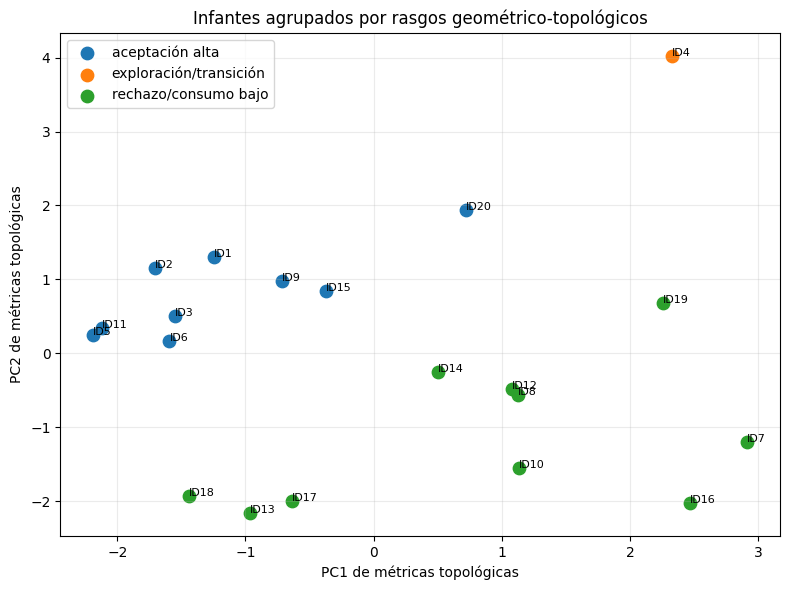

In [16]:
pca_ids = PCA(n_components=2, random_state=42).fit_transform(Xc_scaled)
plot_cluster = traj_features.copy()
plot_cluster['PC1'] = pca_ids[:, 0]
plot_cluster['PC2'] = pca_ids[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for label, sub in plot_cluster.groupby('cluster_interpretacion'):
    ax.scatter(sub['PC1'], sub['PC2'], s=80, label=label)
    for _, row in sub.iterrows():
        ax.text(row['PC1'], row['PC2'], row['id'], fontsize=8)
ax.set_xlabel('PC1 de métricas topológicas')
ax.set_ylabel('PC2 de métricas topológicas')
ax.set_title('Infantes agrupados por rasgos geométrico-topológicos')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_clusters_infantes_pca.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Hallazgos topológicos preliminares

- En dimensión 0, la nube final de valencia–arousal se conecta gradualmente: las escalas de muerte H0 del MST permiten distinguir puntos/regiones más aisladas de la masa principal.
- La aproximación de Betti indica que los ciclos del grafo aparecen al conectar puntos, pero se rellenan rápidamente con triángulos; por ello, en esta representación no hay evidencia fuerte de huecos H1 persistentes.
- Las trayectorias por infante sí muestran diferencias de forma: algunos infantes tienen recorridos cortos y compactos, mientras otros muestran mayor tortuosidad y dispersión.
- El grafo tipo Mapper ordena regiones de bajo consumo/alto rechazo hacia regiones de alto consumo/bajo rechazo, lo que sugiere un continuo descriptivo entre rechazo, transición y aceptación.
- Los clusters topológicos deben interpretarse como segmentos exploratorios, no como diagnóstico. Sirven para guiar análisis posteriores y revisar casos representativos.